# Required Functions

In [25]:
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.pyplot import pie,axis,show
%matplotlib inline

In [41]:
import pandas as pd
import json
import re
def load_dataframe(filename):
    with open(filename,'r') as f:
        df = pd.DataFrame(json.load(f))
        df['index'] = range(len(df))
        return df

def drop_cols(df,dropcols):
    return df[list(filter(lambda x:not re.search('|'.join(dropcols),x) ,df.columns))]

def plot_pie_chart(df,dropcols,dropre=['min','max','avg'],count=None):
    df = df.drop(dropcols,axis=1)
    df = drop_cols(df,dropre)
    count = len(df) if count is None else count
    for i in range(count):
        dfi = df.loc[str(i),:]
        axis('equal')
        labels = [ '-'.join(list(map(str,item))) for item in list(dfi.items())]
        pie(dfi, labels=labels,startangle=0)
        show()

def plot_pie_chart_(df,dropcols,dropre=['min','max','avg'],count=None,figdim=10):
    df = df.drop(dropcols,axis=1)
    df = drop_cols(df,dropre)
    count = len(df) if count is None else count
    rows = max(int(count/2),1)
    cols = 2 if count>1 else 1
    figsize = tuple([ figdim*rows for _ in range(rows) ])
    fig, ax = plt.subplots(rows,cols,figsize=figsize)
        
    for i in range(count):
        dfi = df.loc[str(i),:]
        ax = fig.add_subplot(rows,cols,(i%cols)+1)
        labels = [ '-'.join(list(map(str,item))) for item in list(dfi.items())]
        _, _ = ax.pie(dft.loc['0',:], startangle=0,labels=labels)
        ax.axis('equal')

def list_detections(output):
    dets_d = {}
    for ko in output.keys():
        d = output[ko]
        dets = []
        for k in d.keys():
            dc = d[k]
            dets.append(dc['output']['labels_detected'])
        dets_d[ko]=dets
    return dets_d

def count_elems(dct):
    count = {}
    sums = {}
    for k in dct.keys():
        count[k] = list(map(lambda l:len(l) ,dct[k]))
        sums[k] = sum(count[k])
    return count,sums

def read_dict(jsonfile):
    op = {}
    with open(jsonfile,'r') as f:
        op = json.load(f)
    return op

def get_intervals_data():
    its = list(map(read_dict,intervals_dicts))
    return its

def get_info_what_key(dct,key):
    for i in dct.keys():
        d = dct[i]
        for k in d.keys():
            if d[k]['key']==key:
                return k

def get_int_info(dct):
    res = {}
    for i in dct.keys():
        d = dct[i]
        res[i]={}
        for k in d.keys():
            key = d[k]['key']
            res[i][key]=[d[k]['info'],d[k]['success']]
            #res[i][key]['what']=k
    return res

def info_det(dct):
    res = {}
    for i in dct.keys():
        res[i] = dct[i]['detect']
    return res

# Fetch & Load Data

In [71]:
df_files = ['detection_model-time.json','extractor-time.json']
output_data_dict_file = 'output_data.json' 
intervals_dicts = ['ext-intervals_data.json','det-intervals_data.json']

In [72]:
drop_columns = True
drop_re=['min','max'] #drop all columns that have these words
dfs = list(map(load_dataframe,df_files))
if drop_columns:
    dfs = list(map(lambda d:drop_cols(d,drop_re),dfs))
data_dm,data_ex = dfs 
#dfex - DataFrame of extractor (main program)
#dfdm - DataFrame of Detector model
output_dict = read_dict(output_data_dict_file)

dts = list(map(get_int_info,get_intervals_data()))
ints_ex,ints_dm = list(map(info_det,dts)) #intervals data

# Inspect Data

In [73]:
print(data_ex.columns,'\n',data_dm.columns)

Index(['Total_time', 'download_video', 'detect-avg', 'name', 'input_file',
       'fetch_frame-total', 'load_video_file', 'load_model', 'detect-total',
       'init&prepare_model', 'save_annotations', 'fetch_frame-avg',
       'video_duration', 'video_file_size', 'index'],
      dtype='object') 
 Index(['detect-avg', 'name', 'post_detection_ops-total', 'input_file',
       'post_detection_ops-avg', 'load_model', 'import_deps', 'detect-total',
       'init_model', 'video_duration', 'video_file_size', 'index'],
      dtype='object')


## DataFrame from extractor (main program)

In [74]:
data_ex #DataFrame of extractor (main program)

,Total_time,download_video,detect-avg,name,input_file,fetch_frame-total,load_video_file,load_model,detect-total,init&prepare_model,save_annotations,fetch_frame-avg,video_duration,video_file_size,index
0,12.4580,1.5790,0.3188,yolo,Lane detection and object detection with OpenC...,0.9712,0.0072,7.6982,1.5940,0.0958,0.3344,0.1942,108.375042,17.0,0
1,16.5669,1.8525,0.2829,yolo,Priceless Reactions to Ronaldo Goals The World...,1.8350,0.0085,8.2504,3.9601,0.0986,0.3762,0.1311,281.633333,30.0,1
2,15.5394,1.7611,0.2699,yolo,Priceless Reactions to Ronaldo Goals The World...,1.5581,0.0071,7.7967,3.7792,0.1083,0.3658,0.1113,281.633333,30.0,2
3,15.6807,1.9107,0.2618,yolo,Priceless Reactions to Ronaldo Goals The World...,1.8524,0.0083,7.6277,3.6649,0.0954,0.3465,0.1323,281.633333,30.0,3


## DataFrame from Detector model

In [75]:
data_dm #DataFrame of Detector model

,detect-avg,name,post_detection_ops-total,input_file,post_detection_ops-avg,load_model,import_deps,detect-total,init_model,video_duration,video_file_size,index
0,0.0292,yolo,0.4043,Lane detection and object detection with OpenC...,0.0809,7.6910,0.0791,0.1461,0.0160,108.375042,17.0,0
1,0.0294,yolo,0.6144,Priceless Reactions to Ronaldo Goals The World...,0.0439,8.2423,0.0807,0.4111,0.0172,281.633333,30.0,1
2,0.0286,yolo,0.5736,Priceless Reactions to Ronaldo Goals The World...,0.0410,7.7885,0.0864,0.4008,0.0213,281.633333,30.0,2
3,0.0285,yolo,0.5605,Priceless Reactions to Ronaldo Goals The World...,0.0400,7.6200,0.0745,0.3986,0.0202,281.633333,30.0,3


# Plot Data

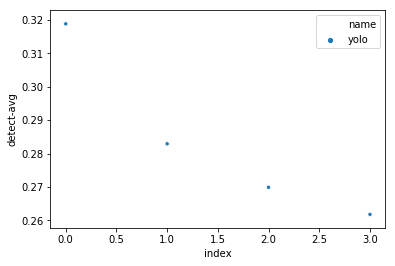

In [76]:
sns.scatterplot(data=data_ex,x='index',y='detect-avg',hue='name',size='name')

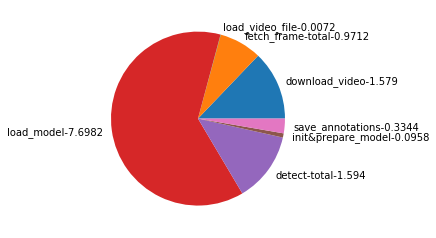

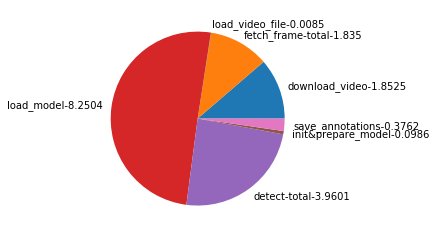

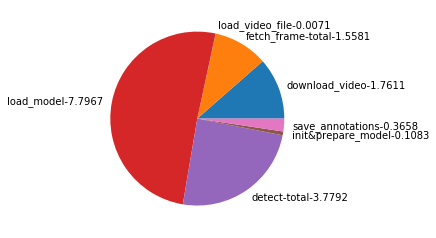

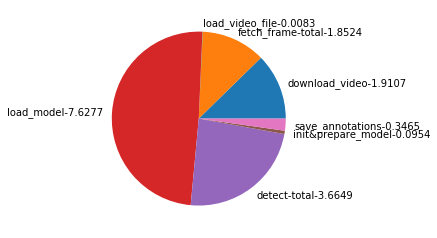

In [77]:
plot_pie_chart(data_ex,['name','index','input_file','Total_time','video_duration','video_file_size'])

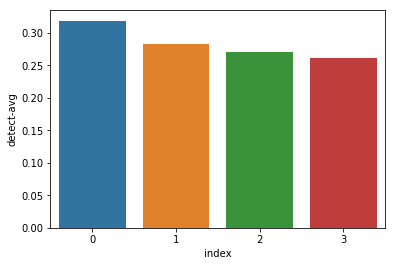

In [78]:
sns.barplot(x='index',y='detect-avg',data=data_ex)

In [83]:
v = list_detections(output_dict)
c,s = count_elems(v)
c['3']

[1, 1, 1, 1, 2, 4, 1, 1, 1, 6, 1, 2, 1]

In [82]:
len(v['3'])

13

In [91]:
ints_dm['3'][1]

[True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True]

In [60]:
output_dict

{'0': {'Lane detection and object detection with OpenCV & TensorFlow-0040s.jpg': {'output': {'bounding_boxes': [[742,
      374,
      826,
      322]],
    'labels_detected': ['car']},
   'labels_matched': ['car'],
   'time': 0.2780029773712158}},
 '1': {'Priceless Reactions to Ronaldo Goals The World Will Never Forget!-0140s.jpg': {'output': {'bounding_boxes': [[35,
      554,
      1127,
      148]],
    'labels_detected': ['person']},
   'labels_matched': ['person'],
   'time': 0.2609519958496094},
  'Priceless Reactions to Ronaldo Goals The World Will Never Forget!-0020s.jpg': {'output': {'bounding_boxes': [[143,
      685,
      1149,
      57]],
    'labels_detected': ['person']},
   'labels_matched': ['person'],
   'time': 0.3333609104156494},
  'Priceless Reactions to Ronaldo Goals The World Will Never Forget!-0060s.jpg': {'output': {'bounding_boxes': [[184,
      658,
      1080,
      76]],
    'labels_detected': ['person']},
   'labels_matched': ['person'],
   'time': 0.305